  Ticker  Correlation       P-value
0   AAPL     0.146633  1.012634e-14
1   GOOG     0.127821  1.626563e-11
2   AMZN     0.082741  1.361372e-05
3   META     0.147971  2.135806e-11
4   NVDA     0.116498  8.510076e-10


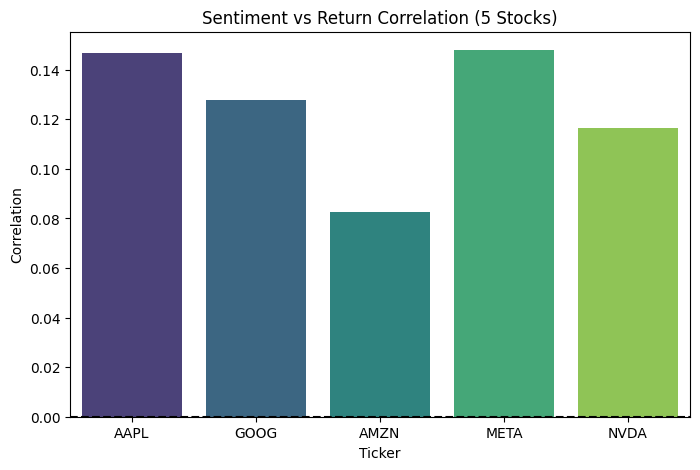

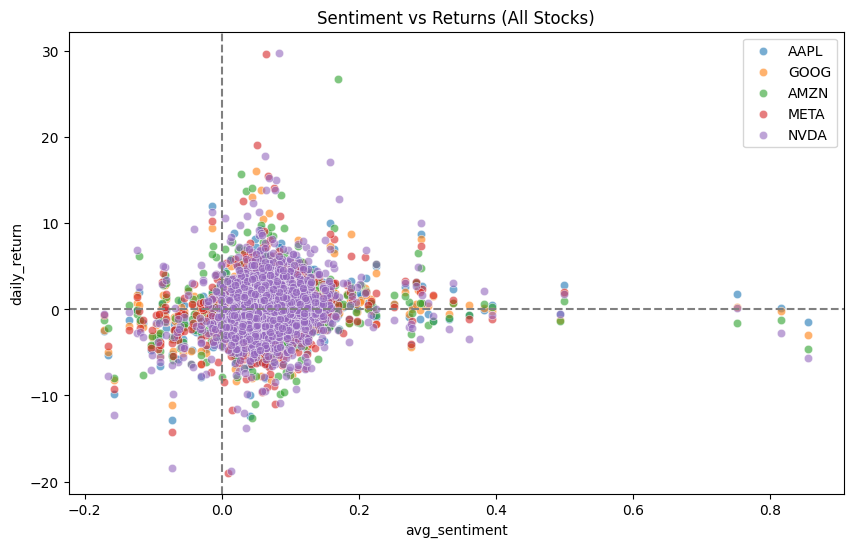

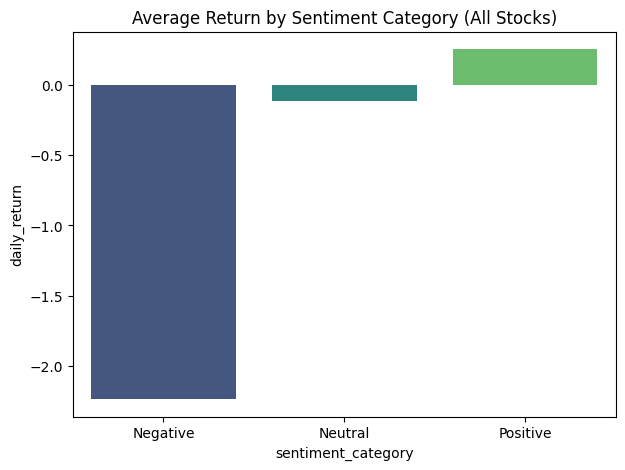

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from scipy.stats import pearsonr

import warnings
warnings.filterwarnings("ignore")

# -----------------------------
# CONFIG
# -----------------------------
tickers = ["AAPL", "GOOG", "AMZN", "META", "NVDA"]

news_path = "../data/raw/raw_analyst_ratings.csv"
stock_path_template = "../data/raw/{}.csv"

analyzer = SentimentIntensityAnalyzer()

results = []

# -----------------------------
# LOAD NEWS (shared for all stocks)
# -----------------------------
news_df = pd.read_csv(news_path)

news_df['date'] = pd.to_datetime(
    news_df['date'],
    format='mixed',
    utc=True,
    errors='coerce'
)

news_df = news_df.dropna(subset=['date'])
news_df['date'] = news_df['date'].dt.tz_localize(None)
news_df['trading_date'] = news_df['date'].dt.normalize()

# sentiment score
news_df['sentiment_score'] = news_df['headline'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)

# -----------------------------
# FUNCTION: SENTIMENT + STOCK MERGE
# -----------------------------
def process_stock(ticker):

    stock_df = pd.read_csv(stock_path_template.format(ticker))

    stock_df['Date'] = pd.to_datetime(stock_df['Date'], errors='coerce')
    stock_df = stock_df.dropna(subset=['Date'])
    stock_df = stock_df.sort_values('Date')

    # daily returns
    stock_df['daily_return'] = stock_df['Close'].pct_change() * 100

    # aggregate sentiment per day
    daily_sentiment = (
        news_df.groupby('trading_date')['sentiment_score']
        .mean()
        .reset_index()
        .rename(columns={'trading_date': 'Date', 'sentiment_score': 'avg_sentiment'})
    )

    # merge
    merged = pd.merge(stock_df, daily_sentiment, on='Date', how='inner')
    merged = merged.dropna()

    if len(merged) < 2:
        return None

    # correlation
    corr, p_value = pearsonr(
        merged['avg_sentiment'],
        merged['daily_return']
    )

    results.append({
        "Ticker": ticker,
        "Correlation": corr,
        "P-value": p_value
    })

    return merged

# -----------------------------
# RUN ALL STOCKS
# -----------------------------
all_data = {}

for t in tickers:
    df = process_stock(t)
    if df is not None:
        all_data[t] = df

# -----------------------------
# SUMMARY TABLE
# -----------------------------
result_df = pd.DataFrame(results)
print(result_df)

# -----------------------------
# CORRELATION BAR PLOT
# -----------------------------
plt.figure(figsize=(8,5))

sns.barplot(
    data=result_df,
    x="Ticker",
    y="Correlation",
    hue="Ticker",
    palette="viridis",
    legend=False
)

plt.title("Sentiment vs Return Correlation (5 Stocks)")
plt.axhline(0, color="black", linestyle="--")
plt.show()

# -----------------------------
# SCATTER PLOT (ALL STOCKS)
# -----------------------------
plt.figure(figsize=(10,6))

for t, df in all_data.items():
    sns.scatterplot(
        data=df,
        x="avg_sentiment",
        y="daily_return",
        label=t,
        alpha=0.6
    )

plt.title("Sentiment vs Returns (All Stocks)")
plt.axhline(0, color="gray", linestyle="--")
plt.axvline(0, color="gray", linestyle="--")
plt.legend()
plt.show()

# -----------------------------
# SENTIMENT CATEGORY ANALYSIS (ALL STOCKS COMBINED)
# -----------------------------
merged_all = pd.concat(all_data.values())

def classify(x):
    if x > 0.05:
        return "Positive"
    elif x < -0.05:
        return "Negative"
    else:
        return "Neutral"

merged_all["sentiment_category"] = merged_all["avg_sentiment"].apply(classify)

category_returns = merged_all.groupby("sentiment_category")["daily_return"].mean().reset_index()

plt.figure(figsize=(7,5))

sns.barplot(
    data=category_returns,
    x="sentiment_category",
    y="daily_return",
    palette="viridis"
)

plt.title("Average Return by Sentiment Category (All Stocks)")
plt.show()
